<a href="https://colab.research.google.com/github/fredrickk-AI4EO/Air-temperature-analysis/blob/main/fredrick_geoai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Using **GeoAI** to download, visualize, and analyse geo/RS data,and create image chips for *Building_detector model*, a **deep learning** model for detecting buildings/ building foot prints.

In [ ]:
%pip install geoai-py

In [2]:
import geoai

In [3]:
print(f"GeoAI package version: {geoai.__version__}")

GeoAI package version: 0.41.2


## Downloading Sample data (hosted on Huggingface).
#### Note: Data can also be downloaded from sites/portals like NAIP, Sentinel etc.

In [4]:
raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train.tif"
)
vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_train_buildings.geojson"

In [5]:
raster_file = geoai.download_file(raster_url)

In [6]:
vector_file = geoai.download_file(vector_url)
print(f"Donloaded {len(vector_file)} vector files")

Donloaded 28 vector files


## Preview the data (raster and vector)

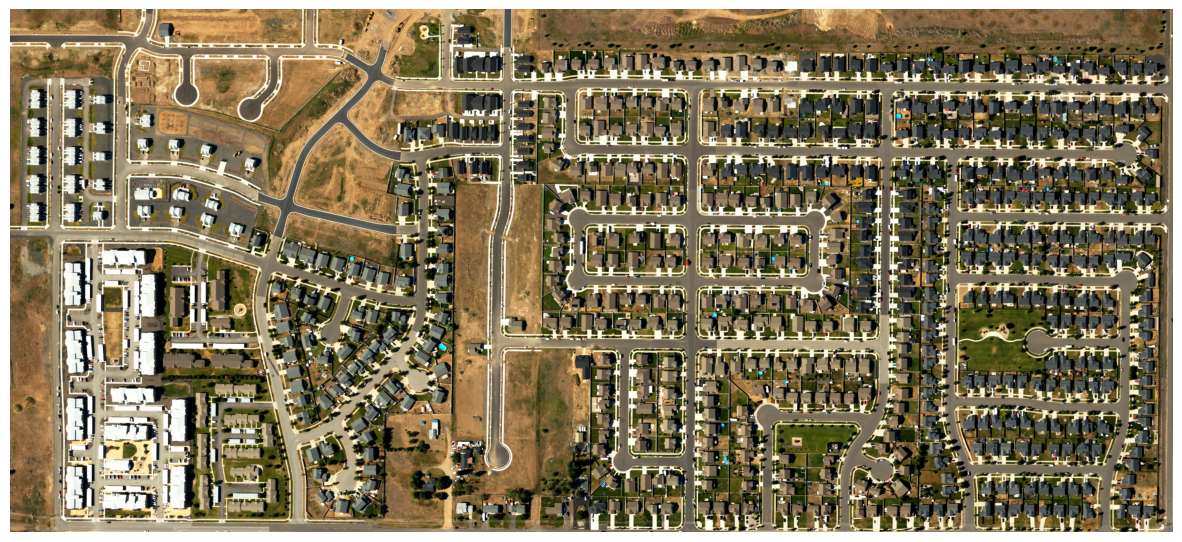

In [7]:
geoai.view_image(raster_file, figsize=(15, 10))

<Axes: >

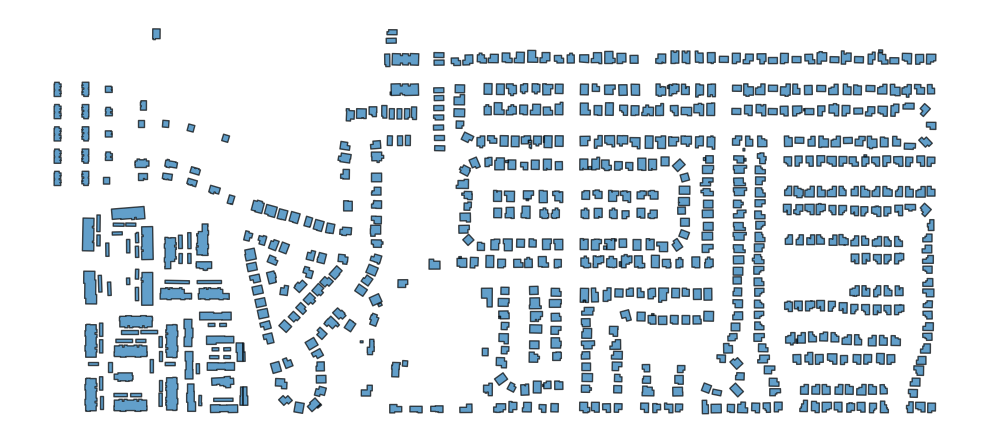

In [8]:
geoai.view_vector(vector_file, figsize=(10, 8))

## Using print_..._info function to view data stats and generate an image previews

===== RASTER INFORMATION: naip_train.tif =====
Driver: GTiff
Dimensions: 2503 x 1126 pixels
Number of bands: 4
Data type: uint8
Coordinate Reference System: EPSG:26911
Georeferenced Bounds: BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6)
Pixel Resolution: 0.6, 0.6
NoData Value: None
----- Band Statistics -----
Band 1:
  Min: 12.00
  Max: 251.00
  Mean: 150.67
  Std Dev: 48.02
Band 2:
  Min: 49.00
  Max: 251.00
  Mean: 141.92
  Std Dev: 43.47
Band 3:
  Min: 53.00
  Max: 251.00
  Mean: 120.90
  Std Dev: 41.78
Band 4:
  Min: 22.00
  Max: 251.00
  Mean: 159.69
  Std Dev: 54.96


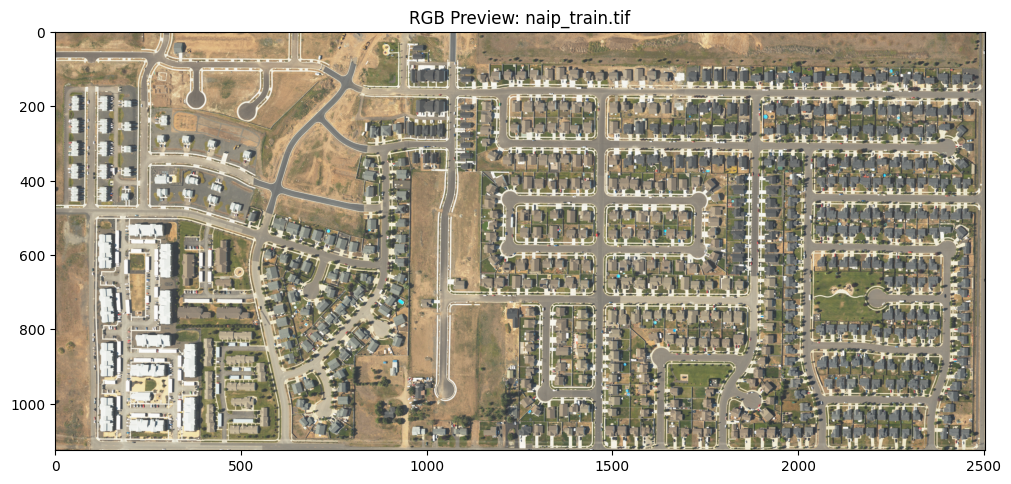

In [9]:
geoai.print_raster_info(raster_file, figsize=(12, 8))

===== VECTOR INFORMATION: naip_train_buildings.geojson =====
Driver: GEOJSON
Feature count: 735
Geometry types: {'Polygon': 735}
Coordinate Reference System: EPSG:4326
Bounds: [-117.6017984, 47.65016239407519, -117.58246913360121, 47.655846]
Number of attributes: 3
Attribute names: id, height, class
----- Attribute Statistics -----
Attribute: id
  min: 1
  max: 735
  mean: 368.0000
  std: 212.3205
  null_count: 0
Attribute: height
  min: 0
  max: 0
  mean: 0.0000
  std: 0.0000
  null_count: 0


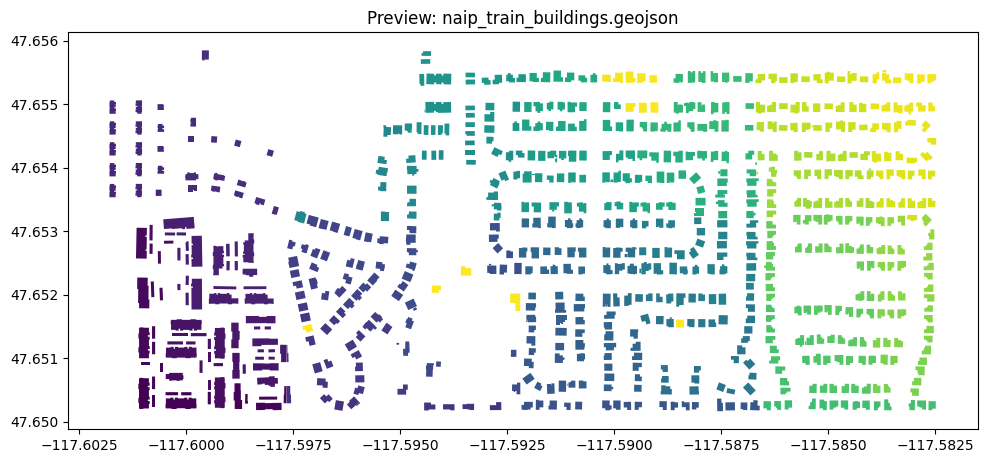

In [10]:
geoai.print_vector_info(vector_file)

### Using get fuction for a stats dictionary

In [11]:
geoai.get_raster_info(raster_file)

{'driver': 'GTiff',
 'width': 2503,
 'height': 1126,
 'count': 4,
 'dtype': 'uint8',
 'crs': 'EPSG:26911',
 'transform': Affine(0.5999999999999953, 0.0, 454780.8,
        0.0, -0.5999999999996691, 5278242.6),
 'bounds': BoundingBox(left=454780.8, bottom=5277567.0, right=456282.6, top=5278242.6),
 'resolution': (0.6, 0.6),
 'nodata': None,
 'band_stats': [{'band': 1,
   'min': 12.0,
   'max': 251.0,
   'mean': 150.6730747259594,
   'std': 48.01908734374099},
  {'band': 2,
   'min': 49.0,
   'max': 251.0,
   'mean': 141.92468895229808,
   'std': 43.46595463573497},
  {'band': 3,
   'min': 53.0,
   'max': 251.0,
   'mean': 120.89909373405554,
   'std': 41.78086244480775},
  {'band': 4,
   'min': 22.0,
   'max': 251.0,
   'mean': 159.68995855062735,
   'std': 54.95588423977727}]}

In [12]:
geoai.get_vector_info(vector_file)

{'file_path': 'naip_train_buildings.geojson',
 'driver': 'GEOJSON',
 'feature_count': 735,
 'crs': 'EPSG:4326',
 'geometry_type': "{'Polygon': 735}",
 'attribute_count': 3,
 'attribute_names': ['id', 'height', 'class'],
 'bounds': [-117.6017984, 47.65016239407519, -117.58246913360121, 47.655846],
 'attribute_stats': {'id': {'min': 1,
   'max': 735,
   'mean': np.float64(368.0),
   'std': 212.3205124334434,
   'null_count': np.int64(0)},
  'height': {'min': 0,
   'max': 0,
   'mean': np.float64(0.0),
   'std': 0.0,
   'null_count': np.int64(0)}}}

## Coverting vector to raster data

In [13]:
output_rchip = vector_file.replace(".geojson", ".tif")
geoai.vector_to_raster(vector_file, output_rchip, reference_raster=raster_file)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

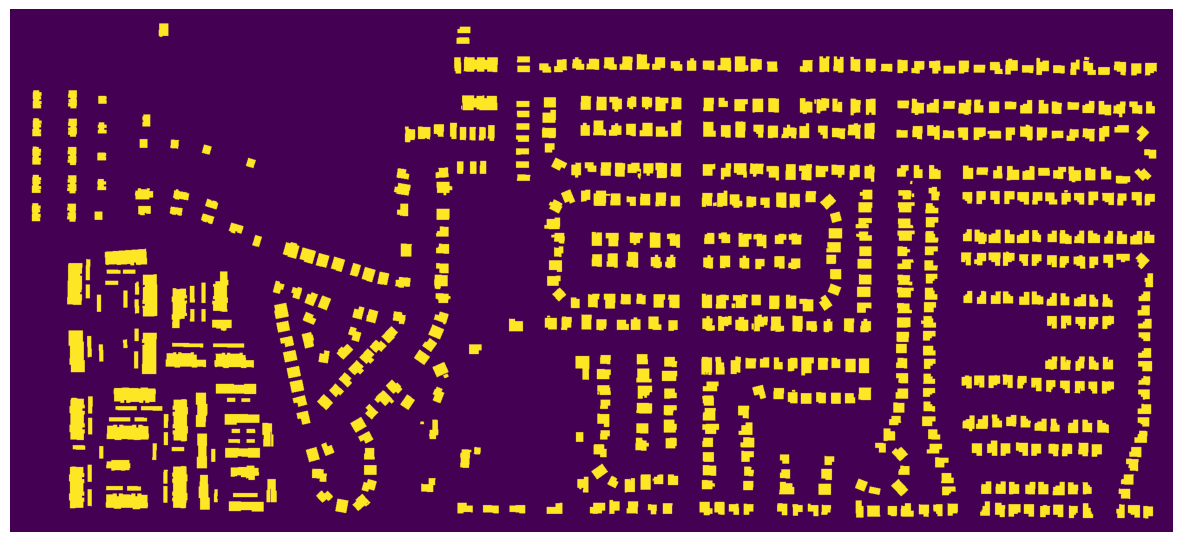

In [14]:
geoai.view_image(output_rchip, figsize=(15, 10))

## Creating/Generating image chips

In [15]:
deepl_chips = geoai.export_geotiff_tiles(
    in_raster= raster_file,
    out_folder= "chip_output",
    in_class_data= vector_file,
    tile_size=512,
    stride=256,
    buffer_radius=0,
    create_overview=True
)

Generated: 36, With features: 36: 100%|██████████| 36/36 [00:13<00:00,  2.70it/s]


## Preview(ing) the image chips

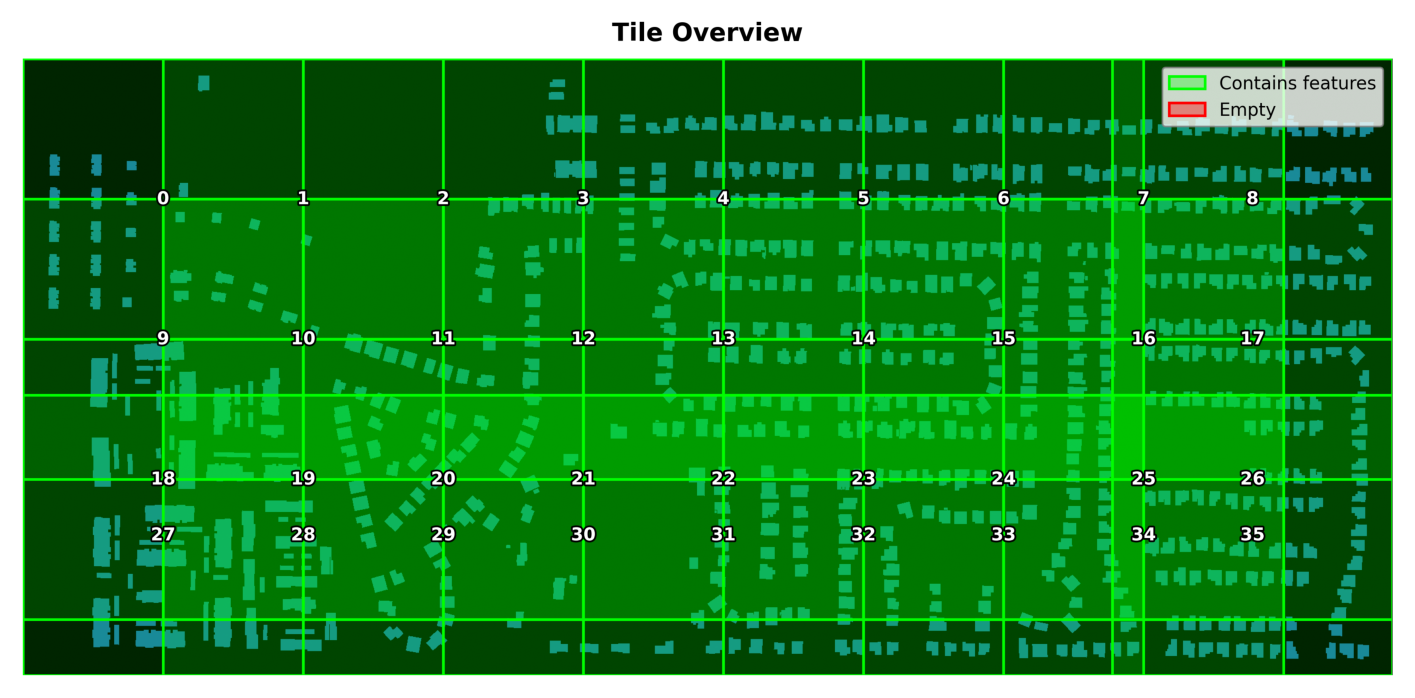

In [16]:
geoai.view_image("/content/chip_output/overview.png", figsize=(18, 10))

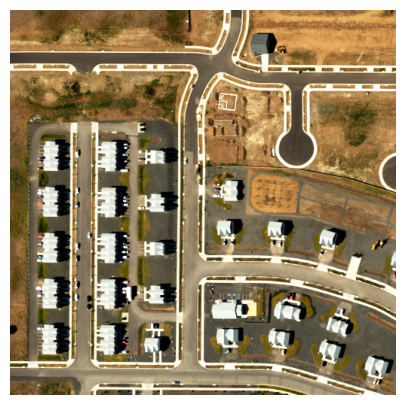

In [17]:
geoai.view_image("/content/chip_output/images/tile_000000.tif")

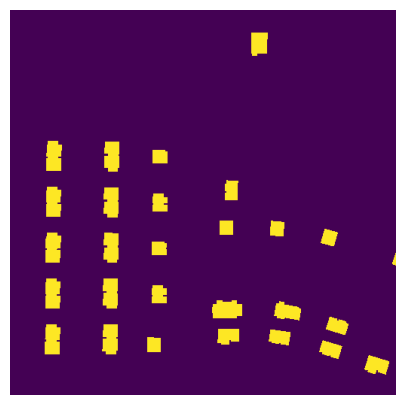

In [18]:
geoai.view_image("/content/chip_output/labels/tile_000000.tif")